# 06 · Machine Learning — 01. Regresión salarial

Modelo de predicción del salario de futbolistas a partir de su rendimiento. El **residuo** del modelo
(salario real − predicho) es el indicador de **sobre/infravaloración**, núcleo del análisis del TFM.

## Resumen de decisiones metodológicas

1. **Validación cruzada `GroupKFold` agrupando por `player_id`:** garantiza que todas las temporadas
   de un mismo jugador caigan en el mismo fold, evitando la **fuga de información** que inflaría
   artificialmente las métricas. Mide la capacidad real de generalizar a jugadores no vistos.
2. **Modelo global** con la posición como feature (se comprobó empíricamente que segmentar por
   posición no mejora — ver sección 5).
3. **Modelo lineal (Ridge)** como modelo final: rinde igual que los modelos de árbol pero es
   interpretable y más parsimonioso (ver sección 4).
4. **Temporada 25/26 reservada** para la aplicación (detección de desajustes), fuera del
   entrenamiento y validación.
5. **Exclusión de las dummies `season_*`** del conjunto de features.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parents[1]
REG_PATH  = ROOT / 'data' / 'modeling' / 'regression' / 'regresion_dataset.csv'
FILT_PATH = ROOT / 'data' / 'clean' / 'master_filtered.csv'

reg = pd.read_csv(REG_PATH)
print(f'Dataset de regresión: {reg.shape[0]:,} × {reg.shape[1]}')

Dataset de regresión: 14,184 × 110


## 2. Recuperar metadatos y preparar los datos

Se recuperan los identificadores de jugador (`player_id`) desde `master_filtered.csv` para poder agrupar
por jugador en la validación cruzada. Se trabaja con **todas las temporadas** del dataset: la validación
*GroupKFold por jugador* (siguiente sección) garantiza una evaluación honesta sin necesidad de reservar
ninguna temporada — basta con que un mismo jugador no aparezca a la vez en entrenamiento y validación.

In [2]:
filt = pd.read_csv(FILT_PATH, dtype={'season': str})
meta = filt[filt['gross_annual_eur'].notna()].reset_index(drop=True)
assert np.allclose(meta['gross_annual_eur'].values, reg['gross_annual_eur'].values), 'Datasets no alineados'

reg['_pid']    = meta['player_id'].values
reg['_season'] = meta['season'].values

# Se excluyen las dummies de temporada de las features: no extrapolan a temporadas
# futuras no vistas. El resto del dataset (todas las temporadas) se usa íntegro.
season_cols = [c for c in reg.columns if c.startswith('season_')]
drop_cols   = ['log_salary','gross_annual_eur','_pid','_season'] + season_cols

X = reg.drop(columns=[c for c in drop_cols if c in reg.columns])
y = reg['log_salary']
groups = reg['_pid']

print(f'Dataset completo: {len(reg):,} filas | Features: {X.shape[1]}')
print(f'Temporadas:       {sorted(reg["_season"].unique())}')
print(f'Jugadores únicos: {groups.nunique():,}')

Dataset completo: 14,184 filas | Features: 103
Temporadas:       ['2021', '2122', '2223', '2324', '2425', '2526']
Jugadores únicos: 5,346


## 3. Validación: GroupKFold por jugador

Se define la estrategia de validación cruzada que se usará en toda la comparativa. Agrupar por
`player_id` es la decisión metodológica central: evita que el modelo "memorice" jugadores vistos en
otras temporadas.

In [3]:
gkf = GroupKFold(n_splits=4)
print('Validación: GroupKFold(4) agrupando por player_id')
print('→ ningún jugador aparece simultáneamente en train y validación')

Validación: GroupKFold(4) agrupando por player_id
→ ningún jugador aparece simultáneamente en train y validación


## 4. Comparativa de modelos

Se comparan modelos lineales (Ridge, Lasso) y de árbol (Random Forest, XGBoost) bajo la misma
validación. El objetivo es elegir el modelo final con criterio empírico.

In [4]:
modelos = {
    'Ridge':        make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Lasso':        make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=5000)),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
                                     reg_lambda=1.5, random_state=42, n_jobs=-1, tree_method='hist'),
}

comparativa = []
for nombre, mdl in modelos.items():
    r2 = cross_val_score(mdl, X, y, groups=groups, cv=gkf, scoring='r2').mean()
    comparativa.append({'modelo': nombre, 'R2': r2})

df_comp = pd.DataFrame(comparativa).sort_values('R2', ascending=False).reset_index(drop=True)
df_comp['R2'] = df_comp['R2'].round(4)
display(df_comp)

,modelo,R2
0,XGBoost,0.5940
1,Ridge,0.5874
2,Lasso,0.5689
3,RandomForest,0.5400


**Conclusión.** Todos los modelos rinden de forma equivalente (R² ≈ 0.56–0.58). Los modelos de árbol no aportan mejora significativa sobre el lineal, probablemente porque la transformación logarítmica del target y la normalización *per-90* ya capturan la estructura del problema. Se elige **Ridge** como modelo final por su interpretabilidad y parsimonia (principio de navaja de Occam).

## 5. ¿Mejora segmentar por posición?

In [5]:
# Comparar: modelo global vs un modelo Ridge independiente por posición
pos_cols = [c for c in reg.columns if c.startswith('position_')]
def get_pos(row):
    for pc in pos_cols:
        if row[pc]==1: return pc.replace('position_','')
    return 'M'
reg['_pos'] = reg[pos_cols].apply(get_pos, axis=1)

# Global (out-of-fold sobre todo el dataset)
pred_global = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=10)),
                                 X, y, groups=groups, cv=gkf)
r2_global = r2_score(y, pred_global)

# Segmentado (un modelo por posición)
pred_seg = np.zeros(len(reg))
for pos in ['K','D','M','F']:
    sub = reg[reg['_pos']==pos]
    Xs = sub.drop(columns=[c for c in drop_cols + ['_pos'] if c in sub.columns])
    Xs = Xs.drop(columns=[c for c in Xs.columns if c.startswith('position_')])
    ys, gs = sub['log_salary'], sub['_pid']
    p = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=10)),
                          Xs, ys, groups=gs, cv=GroupKFold(4))
    pred_seg[(reg['_pos']==pos).values] = p
r2_seg = r2_score(y, pred_seg)

print(f'Global (posición como feature): R² = {r2_global:.4f}')
print(f'Segmentado (4 modelos):         R² = {r2_seg:.4f}')

Global (posición como feature): R² = 0.5877
Segmentado (4 modelos):         R² = 0.5794


**Conclusión.** La segmentación **no** mejora frente al modelo global. Al dividir, cada modelo entrena con muchos menos datos y pierde los patrones compartidos entre posiciones, mientras que el modelo global ya captura las diferencias posicionales mediante la *feature* de posición. Se adopta el **modelo global**.

## 6. Modelo final: Ridge global

Se entrena el Ridge sobre todo el pool 20/21–24/25. Este es el modelo que se aplicará a la 25/26.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
modelo_final = Ridge(alpha=10)
modelo_final.fit(X_scaled, y)

print(f'Modelo final: Ridge (alpha=10) entrenado sobre {len(X):,} observaciones (todas las temporadas)')
print(f'R² de validación (GroupKFold por jugador): {r2_global:.4f}')
print(f'MAE (log): {mean_absolute_error(y, pred_global):.4f}')

Modelo final: Ridge (alpha=10) entrenado sobre 14,184 observaciones (todas las temporadas)
R² de validación (GroupKFold por jugador): 0.5877
MAE (log): 0.6039


## 7. Interpretación: ¿qué determina el salario?

La gran ventaja de un modelo lineal es la **interpretabilidad**. Los coeficientes (sobre features
estandarizadas) indican el efecto de cada variable sobre el log-salario.

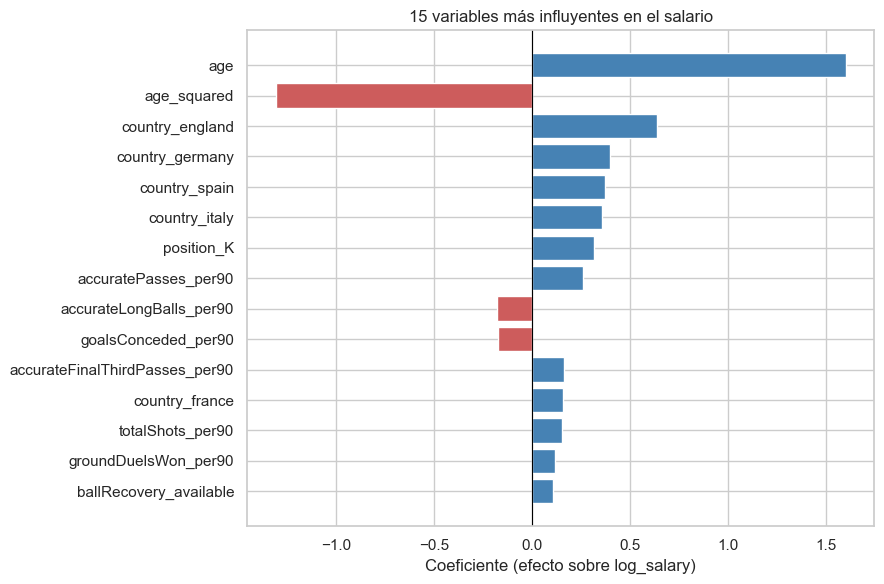

In [7]:
coefs = pd.Series(modelo_final.coef_, index=X.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = coefs.head(15)[::-1]
colors = ['steelblue' if c>0 else 'indianred' for c in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel('Coeficiente (efecto sobre log_salary)')
ax.set_title('15 variables más influyentes en el salario')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

**Lectura de los principales factores:**

- **`age` (+) y `age_squared` (−):** curva de Mincer — el salario crece con la edad hasta un pico (~28-30 años) y luego decrece. Es el patrón clásico de los mercados laborales.
- **`country_england` (+):** la Premier League paga sistemáticamente más que el resto (*premium* de liga), seguida de Bundesliga, Serie A y LaLiga. La liga de referencia es la turca.
- **`accuratePasses_per90` / `accurateFinalThirdPasses_per90` (+):** los jugadores con más volumen y calidad de pase cobran más (proxy de centralidad en el juego).
- **`goalsConceded_per90` y `saves_per90` (−):** encajar goles y acumular paradas (señal de jugar en un equipo defensivamente débil) se asocia a menor salario.

## 8. Detección de sobre/infravalorados

El residuo del modelo (diferencia entre salario real y estimado) es el producto analítico clave: un
residuo positivo indica que el jugador cobra **más** de lo que su rendimiento predice (posible
sobrevaloración), y uno negativo, **menos** (posible infravaloración). Se examinan los casos extremos
de la temporada actual (25/26).

In [8]:
# Predicción out-of-fold para todo el dataset (honesta: cada jugador predicho sin haber entrenado con él)
pred_oof = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=10)),
                              X, y, groups=groups, cv=gkf)

res_all = pd.DataFrame({
    'player':   meta['player'].values,
    'position': meta['position'].values,
    'team':     meta['team'].values,
    'liga':     meta['country'].values,
    'season':   meta['season'].values,
    'salario_real': np.exp(y.values),
    'salario_pred': np.exp(pred_oof),
})
res_all['residuo'] = np.log(res_all['salario_real']) - np.log(res_all['salario_pred'])

# Centrarse en la temporada actual (25/26) para la detección
res = res_all[res_all['season']=='2526'].copy()

def fmt(df):
    df = df.copy()
    df['real_M€'] = (df['salario_real']/1e6).round(2)
    df['pred_M€'] = (df['salario_pred']/1e6).round(2)
    return df[['player','position','team','liga','real_M€','pred_M€']]

print('=== TOP 12 INFRAVALORADOS 25/26 (cobran menos de lo que su rendimiento predice) ===')
display(fmt(res.nsmallest(12, 'residuo')))

print('\n=== TOP 12 SOBREVALORADOS 25/26 (cobran más de lo que su rendimiento predice) ===')
display(fmt(res.nlargest(12, 'residuo')))

=== TOP 12 INFRAVALORADOS 25/26 (cobran menos de lo que su rendimiento predice) ===


,player,position,team,liga,real_M€,pred_M€
2238,Hannibal Mejbri,F,Burnley,england,0.03,1.36
2362,Lyle Foster,F,Burnley,england,0.05,1.44
2289,Harrison Armstrong,M,Everton,england,0.07,1.28
8867,Jacobo Ramón,D,Como,italy,0.30,2.69
11551,Santi Cazorla,M,Real Oviedo,spain,0.19,1.59
6688,Stefan Schimmer,F,1. FC Heidenheim,germany,0.38,3.12
2329,Josh Acheampong,D,Chelsea,england,0.30,2.29
6557,Sheraldo Becker,F,1. FSV Mainz 05,germany,0.75,5.52
2216,Tom Cairney,M,Fulham,england,2.11,14.00
6534,Nikolas Nartey,M,VfB Stuttgart,germany,0.66,4.30



=== TOP 12 SOBREVALORADOS 25/26 (cobran más de lo que su rendimiento predice) ===


,player,position,team,liga,real_M€,pred_M€
13907,Kerem Aktürkoğlu,F,Fenerbahçe,turkey,5.94,0.57
13930,Ederson,K,Fenerbahçe,turkey,13.75,1.37
11464,Nico Williams,F,Athletic Club,spain,16.67,1.77
9180,Dušan Vlahović,F,Juventus,italy,22.22,2.43
11407,Jan Oblak,K,Atlético Madrid,spain,20.83,2.47
4622,Mika Biereth,F,AS Monaco,france,2.87,0.37
13873,N'Golo Kante,M,Fenerbahçe,turkey,6.88,1.03
13911,Wilfried Singo,D,Galatasaray,turkey,6.00,0.91
11467,Unai Simón,K,Athletic Club,spain,8.33,1.34
4612,Morgan Sanson,M,Nice,france,5.09,0.82


## 9. Ejemplos comentados

Algunos casos concretos para ilustrar cómo interpretar los residuos.

In [9]:
# Buscar ejemplos concretos de distintos perfiles
def mostrar(nombre):
    m = res[res['player'].str.contains(nombre, case=False, na=False, regex=False)]
    for _, r in m.iterrows():
        tipo = 'INFRAVALORADO' if r['residuo']<0 else 'SOBREVALORADO'
        print(f"  {r['player']} ({r['position']}, {r['team']}): "
              f"real {r['salario_real']/1e6:.1f}M€ vs predicho {r['salario_pred']/1e6:.1f}M€ → {tipo}")

for nombre in ['Cazorla','Oblak','Nico Williams','Cubarsí','Yamal']:
    mostrar(nombre)

  Santi Cazorla (M, Real Oviedo): real 0.2M€ vs predicho 1.6M€ → INFRAVALORADO
  Jan Oblak (K, Atlético Madrid): real 20.8M€ vs predicho 2.5M€ → SOBREVALORADO
  Nico Williams (F, Athletic Club): real 16.7M€ vs predicho 1.8M€ → SOBREVALORADO
  Pau Cubarsí (D, FC Barcelona): real 4.0M€ vs predicho 2.4M€ → SOBREVALORADO
  Lamine Yamal (F, FC Barcelona): real 16.7M€ vs predicho 5.9M€ → SOBREVALORADO


**Interpretación de los patrones:**

- **Veteranos en equipos modestos** (Cazorla en el Oviedo): aparecen como *infravalorados* — rinden por encima de lo que su salario (bajo, propio de un club recién ascendido) reflejaría.
- **Estrellas consagradas** (Nico Williams, Oblak): aparecen como *sobrevalorados* porque su salario incorpora factores que el modelo no observa (marca, valor de mercado, expectativas, fiabilidad). El residuo grande **no es un error del modelo**: es la señal de que su salario responde a algo más que el rendimiento de una temporada.
- **Jóvenes de élite ya con contrato alto** (Yamal, Cubarsí): pese a su juventud, sus clubes ya les han renovado con fichas elevadas, por lo que el modelo —que solo ve el rendimiento de la temporada— los marca como *sobrevalorados*. Ilustra el límite del enfoque: el salario anticipa un potencial futuro que las stats actuales todavía no respaldan del todo.
- **Porteros de élite** (Oblak): el modelo tiende a infravalorar su rendimiento, por lo que sus fichas reales los sitúan como sobrevalorados; su salario premia trayectoria y fiabilidad más que las stats de una temporada concreta.

## 9.5 Exportación del artefacto para la plataforma

Se exportan las predicciones del modelo a `salarios_predichos.csv` (salario real, estimado y residuo por
jugador y temporada) para que la plataforma Streamlit (fase 07) las consuma sin recalcular.

El modelo final (sección 6) ya está entrenado con **todas las temporadas**, por lo que aquí simplemente
se generan y guardan sus predicciones sobre el conjunto completo. El residuo exportado es la señal de
sobre/infravaloración que utiliza la plataforma.

In [10]:
# El modelo_final ya se entrenó con todas las temporadas (sección 6).
# Se generan sus predicciones sobre el conjunto completo y se exportan.
pred_log_full = modelo_final.predict(X_scaled)

salarios_predichos = pd.DataFrame({
    'player_id':        meta['player_id'].values,
    'season':           meta['season'].values,
    'salario_real':     np.exp(y.values),
    'salario_predicho': np.exp(pred_log_full),
})
salarios_predichos['residuo'] = (
    np.log(salarios_predichos['salario_real']) - np.log(salarios_predichos['salario_predicho'])
)

OUT_PATH = ROOT / 'data' / 'modeling' / 'regression' / 'salarios_predichos.csv'
salarios_predichos.to_csv(OUT_PATH, index=False)
print(f'Exportadas {len(salarios_predichos):,} predicciones a: {OUT_PATH}')
salarios_predichos.head()

Exportadas 14,184 predicciones a: d:\USER\Desktop\TFM\data\modeling\regression\salarios_predichos.csv


,player_id,season,salario_real,salario_predicho,residuo
0,70996,2021,24096205.0,3.047914e+07,-0.234988
1,108579,2021,12048102.0,9.748859e+06,0.211757
2,288205,2021,10843292.0,1.248916e+07,-0.141314
3,189061,2021,6325254.0,1.340358e+07,-0.750972
4,15354,2021,36144307.0,9.409563e+06,1.345793


## 10. Conclusiones

### Modelo
- **Ridge global** con validación `GroupKFold` por jugador. R² ≈ 0.58 — competitivo con los modelos
  de árbol pero más simple e interpretable.
- Se verificó empíricamente que ni los modelos de árbol ni la segmentación por posición mejoran el
  resultado, justificando la elección por parsimonia.

### Sobre el nivel de R²
El R² ≈ 0.58 es **honesto** (sin fuga de información). El componente no explicado refleja factores del
salario ajenos al rendimiento deportivo (valor de mercado, marca, potencial, antigüedad del contrato,
poder de negociación). En este TFM ese componente no es una limitación sino **el fundamento del
análisis**: el residuo es precisamente el indicador de sobre/infravaloración.

### Uso
El residuo sobre la 25/26 identifica desajustes salariales. Combinado con el sistema de similitud
(05_03), permite proponer reemplazos de perfil parecido y menor coste — la funcionalidad central de la
plataforma final.

### Líneas de mejora (discusión)
- Incorporar el **valor de mercado** (p. ej. Transfermarkt) como variable elevaría el R², a costa de
  reducir la pureza conceptual del enfoque "rendimiento → salario".
- Variables de **potencial/contrato** ayudarían a explicar los residuos de los jugadores jóvenes.